In [4]:
import numpy as np
from scipy import optimize, integrate, interpolate, signal
import matplotlib.pyplot as plt

Integral from 0 to 10: 1.2815 ± 2.06e-14


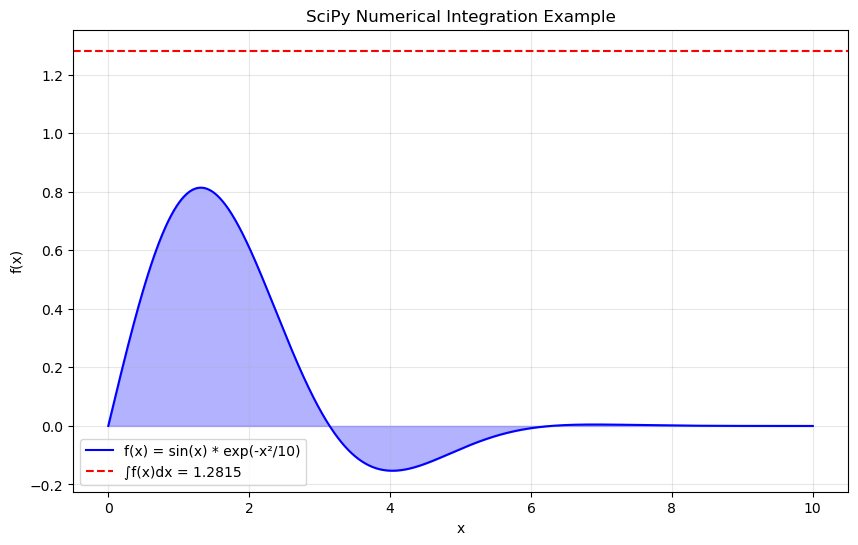

In [5]:
# Define a function to integrate
def f(x):
    return np.sin(x) * np.exp(-x**2 / 10)

# Generate x values
x = np.linspace(0, 10, 1000)
y = f(x)

# Numerical integration using quad
result, error = integrate.quad(f, 0, 10)
print(f"Integral from 0 to 10: {result:.4f} ± {error:.2e}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', label='f(x) = sin(x) * exp(-x²/10)')
plt.fill_between(x, y, alpha=0.3, color='blue')
plt.axhline(result, color='red', linestyle='--', label=f'∫f(x)dx = {result:.4f}')
plt.title('SciPy Numerical Integration Example')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1944088/2129518109.py:39: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 200, using nperseg = 200
  f, Pxx = signal.welch(signal_noisy, 1000)


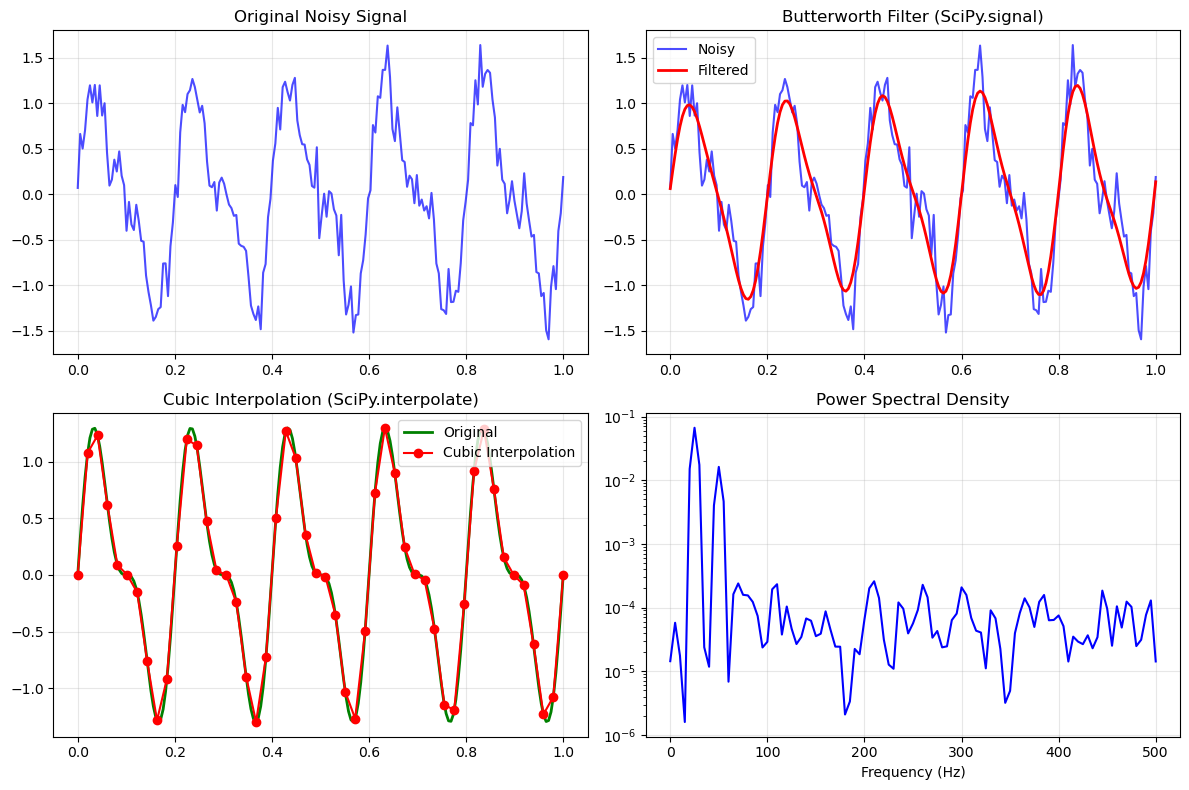

Filter reduced noise by 0.188 → 0.196 std dev


In [6]:
# Generate noisy signal
t = np.linspace(0, 1, 200)
signal_clean = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 10 * t)
signal_noisy = signal_clean + 0.2 * np.random.randn(len(t))

# Apply Butterworth low-pass filter
b, a = signal.butter(4, 0.1)  # 4th order, cutoff at 10% of Nyquist
signal_filtered = signal.filtfilt(b, a, signal_noisy)

# Interpolation example - downsample then interpolate back
t_coarse = np.linspace(0, 1, 50)
interp_func = interpolate.interp1d(t, signal_clean, kind='cubic')
signal_interp = interp_func(t_coarse)

# Plot results
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(t, signal_noisy, 'b-', alpha=0.7, label='Noisy Signal')
plt.title('Original Noisy Signal')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(t, signal_noisy, 'b-', alpha=0.7, label='Noisy')
plt.plot(t, signal_filtered, 'r-', linewidth=2, label='Filtered')
plt.title('Butterworth Filter (SciPy.signal)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(t, signal_clean, 'g-', linewidth=2, label='Original')
plt.plot(t_coarse, signal_interp, 'ro-', markersize=6, label='Cubic Interpolation')
plt.title('Cubic Interpolation (SciPy.interpolate)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
# Power spectral density
f, Pxx = signal.welch(signal_noisy, 1000)
plt.semilogy(f, Pxx, 'b-', label='Noisy PSD')
plt.title('Power Spectral Density')
plt.xlabel('Frequency (Hz)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print filter stats
print(f"Filter reduced noise by {np.std(signal_noisy - signal_clean):.3f} → {np.std(signal_filtered - signal_clean):.3f} std dev")